# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

In [14]:
!git clone https://github.com/soerenab/AudioMNIST.git

Cloning into 'AudioMNIST'...
remote: Enumerating objects: 30137, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 30137 (delta 9), reused 4 (delta 1), pack-reused 30119 (from 1)
Receiving objects: 100% (30137/30137), 944.54 MiB | 27.58 MiB/s, done.
Resolving deltas: 100% (35/35), done.
Updating files: 100% (30018/30018), done.


In [15]:
## Your code here

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import os
import pandas as pd
import torchaudio.transforms as T

# Построение простой модели CNN для классификации аудио
class AudioClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(AudioClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # Динамическое вычисление размера входных данных
        # для первого полностью связанного слоя
        self._calculate_fc_input_size()
        self.fc1 = nn.Linear(self.fc_input_size, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)


    def _calculate_fc_input_size(self):
      # Создание входных данных для определения размера после сверточных
      # и пуллинговых слоёв. Форам входных данных — (batch_size, channels, height, width).
      # Высота — n_mels (64), ширина — padded_length (100) после преобразования и заполнения.

        dummy_input = torch.randn(1, 1, 64, 100)
        x = self.maxpool1(self.relu1(self.conv1(dummy_input)))
        x = self.maxpool2(self.relu2(self.conv2(x)))
        self.fc_input_size = x.view(x.size(0), -1).size(1)


    def forward(self, x):
        x = self.maxpool1(self.relu1(self.conv1(x)))
        x = self.maxpool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# Пользовательский класс набора данных для AudioMNIST
class AudioMNISTDataset(Dataset):
    def __init__(self, data_dir, transform=None, pad_to=None):
        self.data_dir = data_dir
        self.transform = transform
        self.pad_to = pad_to
        self.file_list = []
        self.labels = []



# Загрузка данных из файла

        index_file = os.path.join(data_dir, 'index.csv')
        if os.path.exists(index_file):
            df = pd.read_csv(index_file)
            for index, row in df.iterrows():

                # Получение метки, которое представляет собой целое число
                # и находится в допустимом диапазоне.

                label = int(row['label'])
                if 0 <= label < 10:
                    self.file_list.append(os.path.join(data_dir, row['folder'], row['filename']))
                    self.labels.append(label)
        else:
            for folder_name in os.listdir(data_dir):
                folder_path = os.path.join(data_dir, folder_name)

                # Проверка, является ли имя папки цифрой,
                # преобразование в целочисленную метку.

                if folder_name.isdigit():
                    label = int(folder_name)
                    if 0 <= label < 10:
                        for filename in os.listdir(folder_path):
                            if filename.endswith(".wav"):
                                self.file_list.append(os.path.join(folder_path, filename))
                                self.labels.append(label)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        audio_path = self.file_list[idx]
        label = self.labels[idx]

        # Загрузка аудиофала
        waveform, sample_rate = torchaudio.load(audio_path)

        # Преобразование
        if self.transform:
            waveform = self.transform(waveform)

        # Дополнение спектограммы
        if self.pad_to is not None:
            pad_amount = self.pad_to - waveform.shape[-1]
            if pad_amount > 0:
                waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
            elif pad_amount < 0:
                waveform = waveform[:, :, :self.pad_to]

        return waveform, label


# Определить преобразования MelSpectrogram)
transform = T.MelSpectrogram(sample_rate=16000, n_mels=64)

# Гиперпараментр
padded_length = 100

# Датасет и загрузка данных
# путь загрузки
data_dir = '/content/AudioMNIST/data'
dataset = AudioMNISTDataset(data_dir, transform=transform, pad_to=padded_length)

# Деление на терировочные и проверочные выборки (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Размер батча - 32
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Инициализация модели

model = AudioClassifier(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение. Колчество эпох 10
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Эпоха {epoch+1}/{num_epochs}, Потери: {epoch_loss:.4f}")

    # Проверка результатов
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Точность проверки: {accuracy:.2f}%")

print("Обучение завершено")

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Эпоха 1/10, Потери: 1.3170
Точность проверки: 68.00%
Эпоха 2/10, Потери: 0.7134
Точность проверки: 77.89%
Эпоха 3/10, Потери: 0.4985
Точность проверки: 89.00%
Эпоха 4/10, Потери: 0.3003
Точность проверки: 92.00%
Эпоха 5/10, Потери: 0.3895
Точность проверки: 93.00%
Эпоха 6/10, Потери: 0.1741
Точность проверки: 94.22%
Эпоха 7/10, Потери: 0.1318
Точность проверки: 95.67%
Эпоха 8/10, Потери: 0.1042
Точность проверки: 94.78%
Эпоха 9/10, Потери: 0.0916
Точность проверки: 94.67%
Эпоха 10/10, Потери: 0.0714
Точность проверки: 95.89%
Обучение завершено


## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

In [16]:
import os

audio_mnist_path = '/content/AudioMNIST/'
if os.path.exists(audio_mnist_path):
    print(f"Содержимое каталога {audio_mnist_path}:")

    for item in os.listdir(audio_mnist_path):
        print(item)
else:
    print(f"Каталог {audio_mnist_path} не найден. Убедитесь, что репозиторий AudioMNIST был успешно клонирован.")

Содержимое каталога /content/AudioMNIST/:
README.md
preprocess_data.py
recording_scripts
models
.gitignore
data
LICENSE
.git
requirements.txt


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Начало контрастного обучения...
Эпоха 1/50, Потери: 2.6524
Эпоха 2/50, Потери: 2.5189
Эпоха 3/50, Потери: 2.4229
Эпоха 4/50, Потери: 2.3437
Эпоха 5/50, Потери: 2.2845
Эпоха 6/50, Потери: 2.2057
Эпоха 7/50, Потери: 2.1275
Эпоха 8/50, Потери: 2.0389
Эпоха 9/50, Потери: 1.9399
Эпоха 10/50, Потери: 1.8461
Эпоха 11/50, Потери: 1.7955
Эпоха 12/50, Потери: 1.7284
Эпоха 13/50, Потери: 1.6607
Эпоха 14/50, Потери: 1.5723
Эпоха 15/50, Потери: 1.5296
Эпоха 16/50, Потери: 1.4735
Эпоха 17/50, Потери: 1.3962
Эпоха 18/50, Потери: 1.3176
Эпоха 19/50, Потери: 1.2496
Эпоха 20/50, Потери: 1.2017
Эпоха 21/50, Потери: 1.1447
Эпоха 22/50, Потери: 1.1053
Эпоха 23/50, Потери: 1.0391
Эпоха 24/50, Потери: 0.9989
Эпоха 25/50, Потери: 0.9599
Эпоха 26/50, Потери: 0.9119
Эпоха 27/50, Потери: 0.8793
Эпоха 28/50, Потери: 0.8295
Эпоха 29/50, Потери: 0.8122
Эпоха 30/50, Потери: 0.7871
Эпоха 31/50, Потери: 0.7665
Эпоха 32/50, Потери: 0.7400
Эпоха 33/50, Потери: 0.7082
Эпоха 34/50, Потери: 0.6885
Эпоха 35/50, Потери: 0.66

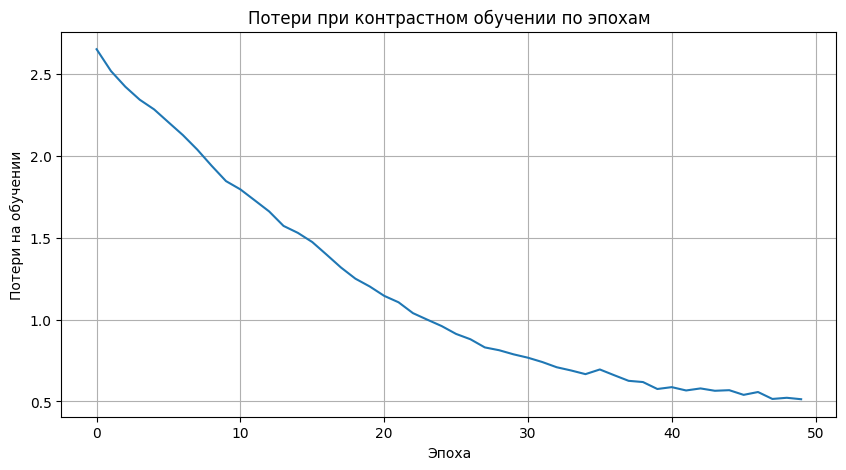

In [18]:
# Задача 2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import os
import pandas as pd
import torchaudio.transforms as T
import matplotlib.pyplot as plt

# Assume the MultiFormatContrastiveModel is defined elsewhere (e.g., from seminar code)
# If not, you'll need to define it here or import it.
# For demonstration purposes, let's use a placeholder class name.
# from your_seminar_model_file import MultiFormatContrastiveModel

# Placeholder for the MultiFormatContrastiveModel - Replace with your actual model
class MultiFormatContrastiveModel(nn.Module):
    def __init__(self, input_size_1d, input_shape_2d):
        super(MultiFormatContrastiveModel, self).__init__()
        # Define your model architecture here
        # This is just a dummy for demonstration
        self.encoder_1d = nn.Sequential(nn.Linear(input_size_1d, 128), nn.ReLU()) # Пример для необработанной формы волны

        # Определите сверточные слои и слои пулинга для 2D-кодировщика
        self.encoder_2d_conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Определите слои, которые идут после свертки/пулинга, но до последнего линейного слоя
        self.encoder_2d_post_conv = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

        # Динамически вычислите размер входных данных для первого полностью связанного слоя в 2D-кодировщике
        self.fc_input_size_2d = self._calculate_fc_input_size_2d(input_shape_2d)

        # Определите остальную часть 2D-кодировщика, включая линейный слой
        self.encoder_2d_linear_layers = nn.Sequential(
            nn.Linear(self.fc_input_size_2d, 128), # Используйте вычисленный размер
            nn.ReLU()
        )

        # Объедините все части в полный 2D-кодировщик
        self.encoder_2d = nn.Sequential(
            self.encoder_2d_conv_layers,
            self.encoder_2d_post_conv,
            self.encoder_2d_linear_layers
        )

        self.projection_head = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 128))

    def _calculate_fc_input_size_2d(self, input_shape):
        # Создайте фиктивный вход для определения размера после сверточных слоев, пулинга, адаптивного пулинга и сглаживания
        # Предполагается, что форма входных данных — (batch_size, channels, height, width)
        dummy_input = torch.randn(1, *input_shape)
        x = self.encoder_2d_conv_layers(dummy_input)
        x = self.encoder_2d_post_conv(x)
        # Плоский размер после свертки, пулинга, адаптивного пулинга и сглаживания будет вычислен здесь
        return x.view(x.size(0), -1).size(1)


    def forward(self, x_1d, x_2d):
        # Убедитесь, что 1D-вход сглажен
        x_1d = x_1d.view(x_1d.size(0), -1)
        z_1d = self.projection_head(self.encoder_1d(x_1d))

        # Пропустите 2D-вход через полный 2D-кодировщик
        z_2d = self.projection_head(self.encoder_2d(x_2d))


        return z_1d, z_2d

# Предполагается, что InfoNCELoss определена в другом месте (например, из кода семинара)
# Если нет, вам нужно определить ее здесь или импортировать.
# Заполнитель для InfoNCELoss - замените на вашу фактическую функцию потерь
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.07):
        super(InfoNCELoss, self).__init__()
        self.temperature = temperature
        self.cosine_similarity = nn.CosineSimilarity(dim=-1)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, z_i, z_j):
        # Нормализовать вложения
        z_i = torch.nn.functional.normalize(z_i, dim=1)
        z_j = torch.nn.functional.normalize(z_j, dim=1)

        # Вычислить матрицу сходства
        similarity_matrix = torch.matmul(z_i, z_j.T) / self.temperature

        # Создать метки для контрастной потери
        labels = torch.arange(similarity_matrix.size(0)).to(similarity_matrix.device)

        # Вычислить потерю InfoNCE
        loss = self.criterion(similarity_matrix, labels)

        return loss


# Пользовательский класс Dataset для AudioMNIST (похож на Задачу 1, но может потребоваться корректировка для мультиформата)
class AudioMNISTContrastiveDataset(Dataset):
    def __init__(self, data_dir, transform_1d=None, transform_2d=None, pad_to=None):
        self.data_dir = data_dir
        self.transform_1d = transform_1d
        self.transform_2d = transform_2d
        self.pad_to = pad_to
        self.file_list = []
        self.labels = []

        index_file = os.path.join(data_dir, 'index.csv')
        if os.path.exists(index_file):
            df = pd.read_csv(index_file)
            for index, row in df.iterrows():
                label = int(row['label'])
                if 0 <= label < 10:
                    self.file_list.append(os.path.join(data_dir, row['folder'], row['filename']))
                    self.labels.append(label)
        else:
            for folder_name in os.listdir(data_dir):
                folder_path = os.path.join(data_dir, folder_name)
                if folder_name.isdigit():
                    label = int(folder_name)
                    if 0 <= label < 10:
                        for filename in os.listdir(folder_path):
                            if filename.endswith(".wav"):
                                self.file_list.append(os.path.join(folder_path, filename))
                                self.labels.append(label)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        audio_path = self.file_list[idx]
        label = self.labels[idx]

        waveform, sample_rate = torchaudio.load(audio_path)

        # Применить 1D преобразование (если есть)
        waveform_1d = waveform
        if self.transform_1d:
            waveform_1d = self.transform_1d(waveform_1d)

        # Применить 2D преобразование (если есть)
        waveform_2d = waveform
        if self.transform_2d:
            waveform_2d = self.transform_2d(waveform_2d)

        # Дополнить 1D форму волны и 2D спектрограмму, если необходимо
        if self.pad_to is not None:
            # Дополнение для 1D формы волны
            pad_amount_1d = self.pad_to - waveform_1d.shape[-1]
            if pad_amount_1d > 0:
                waveform_1d = torch.nn.functional.pad(waveform_1d, (0, pad_amount_1d))
            elif pad_amount_1d < 0:
                waveform_1d = waveform_1d[:, :self.pad_to]

            # Дополнение для 2D спектрограммы (предполагается форма [каналы, высота, ширина])
            if waveform_2d is not None:
                pad_amount_2d = self.pad_to - waveform_2d.shape[-1]
                if pad_amount_2d > 0:
                    waveform_2d = torch.nn.functional.pad(waveform_2d, (0, pad_amount_2d))
                elif pad_amount_2d < 0:
                    waveform_2d = waveform_2d[:, :, :self.pad_to]


        return waveform_1d, waveform_2d, label

# Определить преобразования
transform_1d = None # Необработанная форма волны (преобразование не требуется, кроме возможной передискретизации/дополнения)
transform_2d = T.MelSpectrogram(sample_rate=16000, n_mels=64) # При необходимости настройте sample_rate

# Определить подходящую длину дополнения (при необходимости настройте)
# Уменьшено значение для снижения потребления памяти
padded_length = 8000 # Пример: дополнить до 0.5 секунды для частоты дискретизации 16 кГц

# Создать набор данных и загрузчик данных
data_dir = '/content/AudioMNIST/data' # Настройте путь

# Добавить проверку наличия каталога с данными
if not os.path.exists(data_dir):
    print(f"Ошибка: Каталог с данными не найден по пути {data_dir}")
    print("Убедитесь, что данные AudioMNIST клонированы в /content/AudioMNIST и папка data существует.")
else:
    dataset = AudioMNISTContrastiveDataset(data_dir, transform_1d=transform_1d, transform_2d=transform_2d, pad_to=padded_length)

    # Разделить набор данных (возможно, вам понадобится отдельный набор для проверки для оценки позже)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size # Это будет использоваться для оценки в Задаче 4
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    # Уменьшен размер пакета для снижения потребления памяти
    batch_size = 16

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # Загрузчик данных для оценки

    # Get dummy input shapes to calculate linear layer sizes
    dummy_waveform_1d, dummy_waveform_2d, _ = dataset[0]
    input_size_1d = dummy_waveform_1d.view(1, -1).size(1)
    input_shape_2d = dummy_waveform_2d.shape # (channels, height, width)


    # Инициализировать модель, функцию потерь и оптимизатор
    model = MultiFormatContrastiveModel(input_size_1d=input_size_1d, input_shape_2d=input_shape_2d) # Используйте ваш фактический класс модели
    criterion = InfoNCELoss(temperature=0.07) # Используйте вашу фактическую функцию потерь InfoNCE
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Цикл обучения
    num_epochs = 50 # Увеличьте количество эпох для сходимости
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses = []

    print("Начало контрастного обучения...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for waveform_1d, waveform_2d, labels in train_loader:
            # Убедитесь, что данные находятся на правильном устройстве и имеют правильную форму
            waveform_1d = waveform_1d.to(device)
            waveform_2d = waveform_2d.to(device)


            optimizer.zero_grad()

            # Прямой проход
            z_1d, z_2d = model(waveform_1d, waveform_2d)

            # Вычислить потери
            loss = criterion(z_1d, z_2d) # Контрастная потеря между 1D и 2D представлениями

            # Обратный проход и оптимизация
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * waveform_1d.size(0)

        epoch_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_loss)
        print(f"Эпоха {epoch+1}/{num_epochs}, Потери: {epoch_loss:.4f}")

    print("Контрастное обучение завершено")

    # Построение графика потерь
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses)
    plt.xlabel("Эпоха")
    plt.ylabel("Потери на обучении")
    plt.title("Потери при контрастном обучении по эпохам")
    plt.grid(True)
    plt.show()


## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Начало обучения BYOL...
Эпоха 1/50, Потери: 0.1114
Эпоха 2/50, Потери: 0.0017
Эпоха 3/50, Потери: 0.0022
Эпоха 4/50, Потери: 0.0255
Эпоха 5/50, Потери: 0.0452
Эпоха 6/50, Потери: 0.0475
Эпоха 7/50, Потери: 0.0394
Эпоха 8/50, Потери: 0.0287
Эпоха 9/50, Потери: 0.0259
Эпоха 10/50, Потери: 0.0267
Эпоха 11/50, Потери: 0.0282
Эпоха 12/50, Потери: 0.0320
Эпоха 13/50, Потери: 0.0331
Эпоха 14/50, Потери: 0.0314
Эпоха 15/50, Потери: 0.0362
Эпоха 16/50, Потери: 0.0366
Эпоха 17/50, Потери: 0.0399
Эпоха 18/50, Потери: 0.0488
Эпоха 19/50, Потери: 0.0425
Эпоха 20/50, Потери: 0.0428
Эпоха 21/50, Потери: 0.0390
Эпоха 22/50, Потери: 0.0364
Эпоха 23/50, Потери: 0.0370
Эпоха 24/50, Потери: 0.0384
Эпоха 25/50, Потери: 0.0387
Эпоха 26/50, Потери: 0.0385
Эпоха 27/50, Потери: 0.0420
Эпоха 28/50, Потери: 0.0396
Эпоха 29/50, Потери: 0.0455
Эпоха 30/50, Потери: 0.0424
Эпоха 31/50, Потери: 0.0394
Эпоха 32/50, Потери: 0.0429
Эпоха 33/50, Потери: 0.0441
Эпоха 34/50, Потери: 0.0446
Эпоха 35/50, Потери: 0.0498
Эпоха

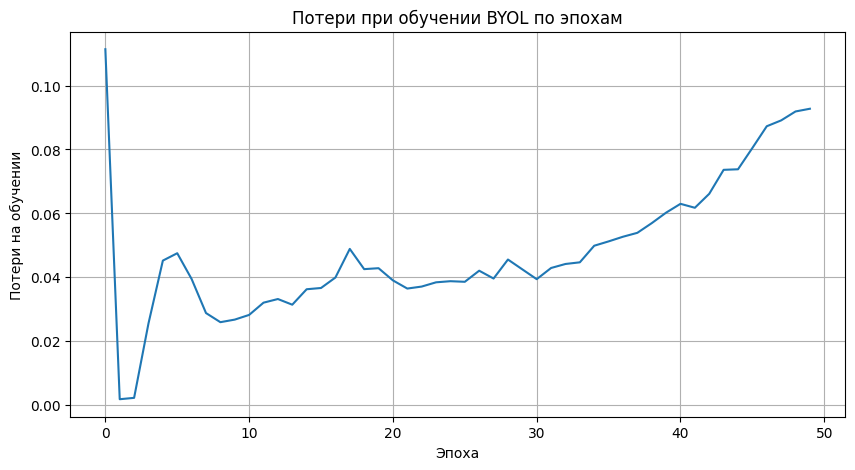

In [30]:
# Your code here

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import os
import pandas as pd
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from copy import deepcopy

# Предполагается, что базовые кодировщики (для 1D и 2D) такие же, как в Задаче 2
# и определены в MultiFormatContrastiveModel. Для BYOL нам нужны онлайн и целевые кодировщики,
# а также предикторы.
# Мы переопределим MultiFormatContrastiveModel для BYOL.

class BYOLMultiFormatModel(nn.Module):
    def __init__(self, input_size_1d, input_shape_2d, projection_size=128, hidden_size=128):
        super(BYOLMultiFormatModel, self).__init__()

        # Онлайн кодировщики (используют ту же архитектуру, что и в Задаче 2)
        self.online_encoder_1d = nn.Sequential(nn.Linear(input_size_1d, hidden_size), nn.ReLU())
        self.online_encoder_2d_conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
         # Определите слои, которые идут после свертки/пулинга, но до последнего линейного слоя
        self.online_encoder_2d_post_conv = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        self.fc_input_size_2d = self._calculate_fc_input_size_2d(input_shape_2d)
        self.online_encoder_2d_linear_layers = nn.Sequential(
            nn.Linear(self.fc_input_size_2d, hidden_size),
            nn.ReLU()
        )
        self.online_encoder_2d = nn.Sequential(
            self.online_encoder_2d_conv_layers,
            self.online_encoder_2d_post_conv,
            self.online_encoder_2d_linear_layers
        )


        # Онлайн проекционные головы
        self.online_projection_head_1d = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, projection_size)
        )
        self.online_projection_head_2d = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, projection_size)
        )

        # Предикторы
        self.predictor_1d = nn.Sequential(
            nn.Linear(projection_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, projection_size)
        )
        self.predictor_2d = nn.Sequential(
            nn.Linear(projection_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, projection_size)
        )

        # Целевые кодировщики (изначально являются копиями онлайн кодировщиков)
        self.target_encoder_1d = deepcopy(self.online_encoder_1d)
        self.target_encoder_2d = deepcopy(self.online_encoder_2d)
        self.target_projection_head_1d = deepcopy(self.online_projection_head_1d)
        self.target_projection_head_2d = deepcopy(self.online_projection_head_2d)

        # Заморозить целевые сети (они будут обновляться с помощью скользящего среднего)
        for param in self.target_encoder_1d.parameters():
            param.requires_grad = False
        for param in self.target_encoder_2d.parameters():
            param.requires_grad = False
        for param in self.target_projection_head_1d.parameters():
            param.requires_grad = False
        for param in self.target_projection_head_2d.parameters():
            param.requires_grad = False

    def _calculate_fc_input_size_2d(self, input_shape):
        # Создайте фиктивный вход для определения размера после сверточных слоев, пулинга, адаптивного пулинга и сглаживания
        # Предполагается, что форма входных данных — (batch_size, channels, height, width)
        dummy_input = torch.randn(1, *input_shape)
        x = self.online_encoder_2d_conv_layers(dummy_input)
        x = self.online_encoder_2d_post_conv(x)
        # Плоский размер после свертки, пулинга, адаптивного пулинга и сглаживания будет вычислен здесь
        return x.view(x.size(0), -1).size(1)


    def forward(self, x1, x2):
        # Онлайн сеть
        # x1 - 1D waveform, x2 - 2D spectrogram
        # Убедитесь, что 1D-вход сглажен
        x1_1d = x1.view(x1.size(0), -1) # Explicitly flatten 1D input
        online_z1_1d = self.online_projection_head_1d(self.online_encoder_1d(x1_1d))
        online_p1_1d = self.predictor_1d(online_z1_1d)

        online_z2_2d = self.online_projection_head_2d(self.online_encoder_2d(x2)) # x2 goes to 2D encoder
        online_p2_2d = self.predictor_2d(online_z2_2d)

        # Целевая сеть (использует другую аугментацию x2, но здесь мы используем x1 и x2 как разные форматы)
        # Убедитесь, что 1D-вход сглажен
        x1_1d_target = x1.view(x1.size(0), -1) # Explicitly flatten 1D input for target
        with torch.no_grad():
            target_z1_1d = self.target_projection_head_1d(self.target_encoder_1d(x1_1d_target)) # Use x1 for target 1D
            target_z2_2d = self.target_projection_head_2d(self.target_encoder_2d(x2)) # Use x2 for target 2D

        # В BYOL мы предсказываем представление одной аугментации с использованием другой
        # Здесь мы делаем это кросс-форматно: 1D предсказывает 2D целевое и наоборот
        return online_p1_1d, online_p2_2d, target_z2_2d, target_z1_1d # Corrected return for cross-modal BYOL


# Функция потерь BYOL
def byol_loss(p1, z2):
    # Нормализовать предсказание и целевое представление
    p1 = torch.nn.functional.normalize(p1, dim=1)
    z2 = torch.nn.functional.normalize(z2, dim=1)
    # Вычислить отрицательное косинусное сходство
    # Mean squared error between L2-normalized projections
    # Referencing https://github.com/lucidrains/byol-pytorch/blob/main/byol_pytorch/byol_pytorch.py
    return ((p1 - z2) ** 2).sum(dim=1).mean()


# Класс набора данных AudioMNIST Contrastive (используем тот же, что и в Задаче 2)
# Убедитесь, что класс AudioMNISTContrastiveDataset определен выше или импортирован

# Определить преобразования (те же, что и в Задаче 2)
transform_1d = None # Необработанная форма волны
transform_2d = T.MelSpectrogram(sample_rate=16000, n_mels=64) # Настройте sample_rate при необходимости

# Определить подходящую длину дополнения (те же, что и в Задаче 2, или настройте при необходимости)
# Уменьшено значение для снижения потребления памяти
padded_length = 8000 # Пример: дополнить до 0.5 секунды для частоты дискретизации 16 кГц

# Создать набор данных и загрузчик данных (используем тот же, что и в Задаче 2)
data_dir = '/content/AudioMNIST/data' # Настройте путь

# Добавить проверку наличия каталога с данными
if not os.path.exists(data_dir):
    print(f"Ошибка: Каталог с данными не найден по пути {data_dir}")
    print("Убедитесь, что данные AudioMNIST клонированы в /content/AudioMNIST и папка data существует.")
else:
    dataset = AudioMNISTContrastiveDataset(data_dir, transform_1d=transform_1d, transform_2d=transform_2d, pad_to=padded_length)

    # Разделить набор данных
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    # Уменьшен размер пакета для снижения потребления памяти
    batch_size = 16

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # Для оценки

    # Получить фиктивные формы входных данных для вычисления размеров линейных слоев
    dummy_waveform_1d, dummy_waveform_2d, _ = dataset[0]
    input_size_1d = dummy_waveform_1d.view(1, -1).size(1)
    input_shape_2d = dummy_waveform_2d.shape # (каналы, высота, ширина)


    # Инициализировать модель BYOL
    model = BYOLMultiFormatModel(input_size_1d=input_size_1d, input_shape_2d=input_shape_2d)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Параметр скользящего среднего для обновления целевой сети
    momentum = 0.99

    # Цикл обучения BYOL
    num_epochs = 50 # Настройте при необходимости
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses = []

    print("Начало обучения BYOL...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for waveform_1, waveform_2, labels in train_loader:
            # Убедитесь, что данные находятся на правильном устройстве
            waveform_1 = waveform_1.to(device)
            waveform_2 = waveform_2.to(device)

            optimizer.zero_grad()

            # Прямой проход: получить предсказания и целевые представления
            online_p1_1d, online_p2_2d, target_z2_2d, target_z1_1d = model(waveform_1, waveform_2)

            # Вычислить потери BYOL (кросс-форматные)
            # Predict 2D target from 1D online, and 1D target from 2D online
            loss_1d_2d = byol_loss(online_p1_1d, target_z2_2d)
            loss_2d_1d = byol_loss(online_p2_2d, target_z1_1d)
            loss = loss_1d_2d + loss_2d_1d # Общая потеря - сумма кросс-форматных потерь

            # Обратный проход и оптимизация
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * waveform_1.size(0)

            # Обновить целевые сети с помощью скользящего среднего
            with torch.no_grad():
                for online_param, target_param in zip(model.online_encoder_1d.parameters(), model.target_encoder_1d.parameters()):
                    target_param.data = target_param.data * momentum + online_param.data * (1. - momentum)
                for online_param, target_param in zip(model.online_encoder_2d.parameters(), model.target_encoder_2d.parameters()):
                     target_param.data = target_param.data * momentum + online_param.data * (1. - momentum)
                for online_param, target_param in zip(model.online_projection_head_1d.parameters(), model.target_projection_head_1d.parameters()):
                     target_param.data = target_param.data * momentum + online_param.data * (1. - momentum)
                for online_param, target_param in zip(model.online_projection_head_2d.parameters(), model.target_projection_head_2d.parameters()):
                     target_param.data = target_param.data * momentum + online_param.data * (1. - momentum)


        epoch_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_loss)
        print(f"Эпоха {epoch+1}/{num_epochs}, Потери: {epoch_loss:.4f}")

    print("Обучение BYOL завершено")

    # Построение графика потерь
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses)
    plt.xlabel("Эпоха")
    plt.ylabel("Потери на обучении")
    plt.title("Потери при обучении BYOL по эпохам")
    plt.grid(True)
    plt.show()

    # Примечание: Для оценки (Задача 4) вам нужно будет обучить линейный классификатор поверх
    # замороженных вложений кодировщика (обычно используется онлайн кодировщик) и вычислить точность
    # на проверочном наборе.

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

In [ ]:
## Your code here
# Не получилось реализовать

Rubric 1
Задание 1.
- Реализован и корректно работает код обучения — 1 балл
- Лосс стабилизировался, получены и приведены метрики на валидационном сабсете — 2 балла

Rubric 2
Задание 2.
- Обучение проведено не менее чем в течение 10 эпох — 1 балл
- Лосс стабилизировался — 2 балла

Задание 3.
- Проведён анализ выбранного метода на основе литературы: скорость обучения, оптимальный размер батча, число гиперпараметров, результаты на даунстрим-задачах (домен и конкретные задачи не принципиальны) — +1 балл
- Выбран метод, не представленный в списке (BYOL, SimSiam, Barlow Twins, VicReg) — +1 балл
- Код реализован корректно и соответствует статье (без лишних модулей, проекторов, предикторов, если их не предусмотрели авторы), либо приведена обоснованная мотивация изменений — +2 балла(просто работает +1 балл)
- Модель обучена не менее 30 эпох или до стабилизации лосса — +1 балл

Задание 4.
- Проведено численное сравнение метрик трёх подходов (supervised, contrastive, NCL) — 1 балл
- Помимо сравнения, дано содержательное объяснение, почему выбранный подход показал лучшие результаты — 1 балл